In this we are creating a multilayer perceptron for making trigrams.
<br>
-- the aim is to consider 3 words / characters as context and predict the next word/character.<br>
-- for this we are going to create a multilayer perceptron with input layer, then have an hidden layer as an hyperparameter and then finally have an softmax layer to get the probablity distribution to get the next best word.<br>
-- the paper we are refering to consist of an example where 3 words are as context to predict the next word. <br>
-- and we convert each word to 1x30 that is 30 dimension vector.<br>

In [1]:
## making the basic imports
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
## Load the words as in the previous example
words = open("names.txt", 'r').read().splitlines()

## Generate stoi and itos mappings
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}

print(stoi)
print(itos)


{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [3]:
## lets generate the data set with trigrams:
X, Y = [], []
block_size = 3
for w in words:
    context = [0] * block_size ## Since we are operating at character level we create a new block / context window for each word.
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(f"{''.join(itos[i] for i in context)} -----> {itos[ix]}")
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [111]:
## Current dimesions of the dataset

X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [70]:
X.shape

torch.Size([53, 3])

In [112]:
## Lets embed things

C = torch.randn((27,2)) ## This is analogous to 17000 x 30 ---> 27 x 2

## So basically now we have a C array that is 27x2 that sets a 2 dim value for each character in the 27 characters 
## Additionally we we say C[X] we are already havein X of nx3 so for each character in word of X --> X[n[m]] the C assigns a 2 dimensional vector is assigned making it C[X] = Nx3x2

print(X.shape, C.shape, C[X].shape)
print(C[X][0]) ## which is the first context of the first character we predicted with 2 dim embedding for each such char. 
print("-----------------")
print(C[X])

torch.Size([228146, 3]) torch.Size([27, 2]) torch.Size([228146, 3, 2])
tensor([[1.7744, 0.9773],
        [1.7744, 0.9773],
        [1.7744, 0.9773]])
-----------------
tensor([[[ 1.7744,  0.9773],
         [ 1.7744,  0.9773],
         [ 1.7744,  0.9773]],

        [[ 1.7744,  0.9773],
         [ 1.7744,  0.9773],
         [-0.8769,  3.0510]],

        [[ 1.7744,  0.9773],
         [-0.8769,  3.0510],
         [ 0.0146,  0.0564]],

        ...,

        [[ 1.1613, -1.5360],
         [ 1.1613, -1.5360],
         [-1.3362, -0.2246]],

        [[ 1.1613, -1.5360],
         [-1.3362, -0.2246],
         [ 1.1613, -1.5360]],

        [[-1.3362, -0.2246],
         [ 1.1613, -1.5360],
         [ 1.2544,  2.1265]]])


In [113]:
## Now we embed the X with our C.

embed = C[X] ## This is the 53 x 3 x 2 tensor that is input x context_length x embedding dimension.

In [114]:
## Now we code the hidden layer of the neural net.
# We know that the previous layer the outcome was Nx3x2 where 3 is the context size and 2 is the embedding dimenstion.
## now the input to hidden layer is 6xnumber of neurns of hidden layer --> for each 3 inputs (contexts) there are 2 dims so in total there are 6 dims

## How do we get them working.
W1 = torch.randn((embed.shape[1]*embed.shape[2],100)) 
b = torch.randn(100)

# Below is what we want to achieve but we do not have it broadcastable. since embed is Nx3x2 so we view it as Nx6 that is we flatten the big array to [[6 numbers which 3x2]]
h = torch.tanh(embed.view(embed.shape[0],embed.shape[1]*embed.shape[2]) @ W1 + b)
h.shape

torch.Size([228146, 100])

In [115]:
## Now we can add the second layer that is the softmax

W2 = torch.randn((100, h.shape[0]))
b2 = torch.randn(h.shape[0])

In [ ]:
## building the logits and the probablity distribution for the next character
logits = h @ W2 + b2
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)

In [ ]:
loss = -probs[torch.arange(probs.shape[0]), Y].log().mean()
loss

tensor(22.0403)

In [88]:
loss = F.cross_entropy(logits, Y) ## This is something same as previous loss procedure but instead of counts and probs and arange this is a better option

In [89]:
X.shape

torch.Size([53, 3])

In [4]:
## Full Run now:

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

## For all the parameters we need to set the required grad = True so we can adjust the loss later on
for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)


3481

In [8]:
for _ in range(500):
    ## forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    ## backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.4 * p.grad



2.4314329624176025
2.4312877655029297
2.431143045425415
2.430999279022217
2.4308559894561768
2.430712938308716
2.4305708408355713
2.430429220199585
2.430288314819336
2.430147409439087
2.4300074577331543
2.42986798286438
2.4297292232513428
2.429591178894043
2.429453134536743
2.4293160438537598
2.4291791915893555
2.4290430545806885
2.4289071559906006
2.42877197265625
2.4286372661590576
2.4285030364990234
2.4283692836761475
2.428236484527588
2.4281036853790283
2.427971601486206
2.427839756011963
2.427708625793457
2.4275777339935303
2.427447557449341
2.4273176193237305
2.4271883964538574
2.4270596504211426
2.4269309043884277
2.4268031120300293
2.426675796508789
2.426548480987549
2.426421880722046
2.426295757293701
2.4261703491210938
2.4260449409484863
2.425920009613037
2.425795555114746
2.4256715774536133
2.4255478382110596
2.4254250526428223
2.425302028656006
2.4251797199249268
2.4250576496124268
2.424936294555664
2.4248151779174805
2.424694299697876
2.424574613571167
2.4244544506073
2.42

In [23]:
## As we have seen this takes a longer time so we create mini batches

## Full Run now:

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

## For all the parameters we need to set the required grad = True so we can adjust the loss later on
for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters))

for _ in range(500):
    ## forward pass
    ## mini batch init
    ix = torch.randint(0, X.shape[0], (32,)) # this creates a mini batch of integers between 0, len X and 32 such batches
    # so instead of using the whole data set we train on 32 randomly picked portions of the dataset to make process faster this do degrades the quality but we do have lot of examples similar 
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    
    ## backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.5 * p.grad
print(loss.item())


3481
3.2551510334014893


In [24]:
## we came to a point where the batch gradient is 2.83 but how it reflects on the full data set
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(3.1599, grad_fn=<NllLossBackward0>)

In [30]:
## How to get good learning rate:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre


In [35]:
## Well this is thing worked to get the outcome faster but we still need to figure out the best learning rate for which we already have the lrs as a set of values between 0,01 to 1 and there are 1000 values 
## We try each value and then we plot the best one as final.
## Full Run now:

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

## For all the parameters we need to set the required grad = True so we can adjust the loss later on
for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters))

lossi = []
lri = []
for i in range(1000):
    ## forward pass
    ## mini batch init
    ix = torch.randint(0, X.shape[0], (32,)) # this creates a mini batch of integers between 0, len X and 32 such batches
    # so instead of using the whole data set we train on 32 randomly picked portions of the dataset to make process faster this do degrades the quality but we do have lot of examples similar 
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    
    ## backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -lrs[i] * p.grad
    
    lri.append(lre[i])
    lossi.append(loss.item())

    print(loss.item())


3481
23.969730377197266
16.994979858398438
22.073474884033203
18.64960289001465
19.91585922241211
20.381580352783203
19.091690063476562
18.454280853271484
22.420177459716797
20.35901641845703
18.699853897094727
18.14088249206543
21.977697372436523
19.6189022064209
17.415874481201172
19.329477310180664
17.321805953979492
18.482425689697266
20.38003921508789
17.98065185546875
19.900814056396484
17.224515914916992
18.724451065063477
17.070066452026367
18.426101684570312
16.23382568359375
20.044376373291016
19.80118751525879
17.026615142822266
17.487682342529297
17.687984466552734
18.36806297302246
18.64584732055664
18.242900848388672
18.847930908203125
17.98183250427246
18.20484161376953
18.610525131225586
18.74395179748535
16.611846923828125
19.495243072509766
19.714677810668945
19.355005264282227
20.030975341796875
17.457866668701172
19.857444763183594
16.670866012573242
17.51068115234375
15.382953643798828
18.34676742553711
16.556900024414062
18.935819625854492
20.87885093688965
17.295

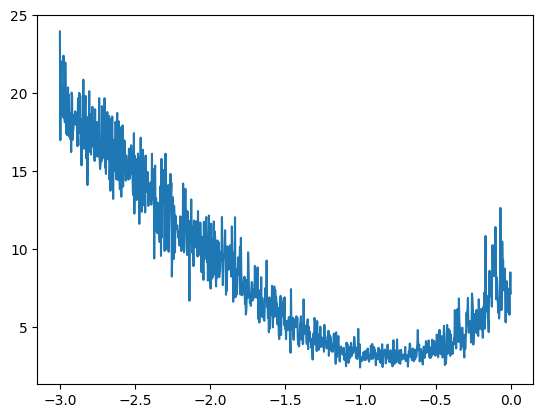

In [36]:
plt.plot(lri, lossi)

In [44]:
## Now we can see from the graph that the lre shows that 10 ^ -1 to 10 ^ 0.5 gives out the best values and hence we can say our value can be somewhere around it.
## Well this is thing worked to get the outcome faster but we still need to figure out the best learning rate for which we already have the lrs as a set of values between 0,01 to 1 and there are 1000 values 
## We try each value and then we plot the best one as final.
## Full Run now:

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

## For all the parameters we need to set the required grad = True so we can adjust the loss later on
for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters))

for i in range(10000):
    ## forward pass
    ## mini batch init
    ix = torch.randint(0, X.shape[0], (32,)) # this creates a mini batch of integers between 0, len X and 32 such batches
    # so instead of using the whole data set we train on 32 randomly picked portions of the dataset to make process faster this do degrades the quality but we do have lot of examples similar 
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    
    ## backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.1 * p.grad
    

print(loss.item())



3481
2.888643503189087


In [45]:
## we came to a point where the batch gradient is 2.83 but how it reflects on the full data set
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.4611, grad_fn=<NllLossBackward0>)

In [49]:
for i in range(10000):
    ## forward pass
    ## mini batch init
    ix = torch.randint(0, X.shape[0], (32,)) # this creates a mini batch of integers between 0, len X and 32 such batches
    # so instead of using the whole data set we train on 32 randomly picked portions of the dataset to make process faster this do degrades the quality but we do have lot of examples similar 
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    
    ## backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.1 * p.grad
    

print(loss.item())

2.581469774246216


In [98]:
## But we cannot train the whole model on the full ds as it will learn the weights and to avoid it we have to do some splits

def build_ds(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        context = block_size*[0]
        for ch in w+".":
            X.append(context)
            Y.append(stoi[ch])
            context = context[1:] + [stoi[ch]]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

## we usually have the train split as 80% val as 10% and test as the rest 10%

import random 

words = open("names.txt", 'r').read().splitlines()
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_ds(words[:n1])
Xval, Yval = build_ds(words[n1:n2])
Xtest, Ytest = build_ds(words[n2:])



In [99]:
## So when we now train we train on the train set only

## The changes in the hidden layer neurons 100 --> 300 are made after monitoring the val loss
## Note we are adding the monitoring the step x loss
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30,200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

## For all the parameters we need to set the required grad = True so we can adjust the loss later on
for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters))

lossi = []
stepi = []
for i in range(50000):
    ## forward pass
    ## mini batch init
    ix = torch.randint(0, Xtr.shape[0], (128,)) # this creates a mini batch of integers between 0, len X and 32 such batches
    # so instead of using the whole data set we train on 32 randomly picked portions of the dataset to make process faster this do degrades the quality but we do have lot of examples similar 
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    ## backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = 0.1 if i < 30000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    lossi.append(loss.item())
    stepi.append(i)

print(loss.item())



11897
2.1750166416168213


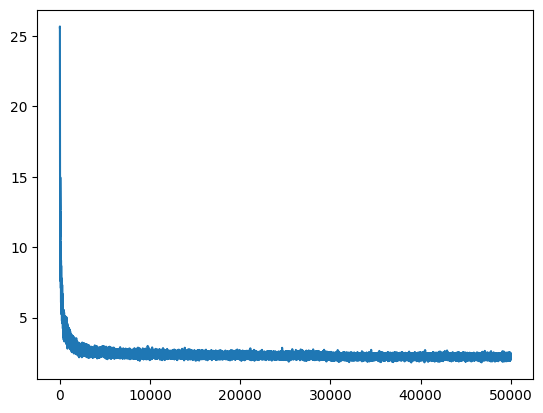

In [100]:
plt.plot(stepi, lossi)
## If we notice the thickness at the bottom what we do is we increase the batchsize now
## For the same we can try now to increase the dimensions of the embedding from 2 --> 3,4, .... to fine tune further

In [101]:
## we came to a point where the batch gradient is 2.83 but how it reflects on the full data set
emb = C[Xval]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yval)
loss

tensor(2.2339, grad_fn=<NllLossBackward0>)

In [102]:
## In the above cells after monitoring the val loss we make changes to the hyper parameters which is the hidden layer we jump from 100 to 300 neurons.

In [107]:
## now we are good to sample from the model
g = torch.Generator().manual_seed(2147483647)
for _ in range(20):
    out = []
    context = block_size * [0]

    while(True):
        embed = C[torch.tensor(context)] # 3x10 
        h = torch.tanh(embed.view(1,-1) @ W1 + b1)  # view let us see the embed as 1 x 30
        logits = h @ W2 + b2
        probs = torch.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
        
    print(f"{"".join(itos[i] for i in out)}")

cerie.
zomanuskilah.
tah.
mellimittainella.
kama.
daksamiyah.
javer.
goton.
molise.
kaugh.
predoren.
emia.
sadel.
niaviyn.
ratlu.
millingh.
tahlys.
kasdr.
breell.
pynw.
